2% done after 22.174492597579956
10% done after 117.00715255737305
25% done after 273.3975884914398
50% done after 544.2742290496826
75% done after 814.9178168773651


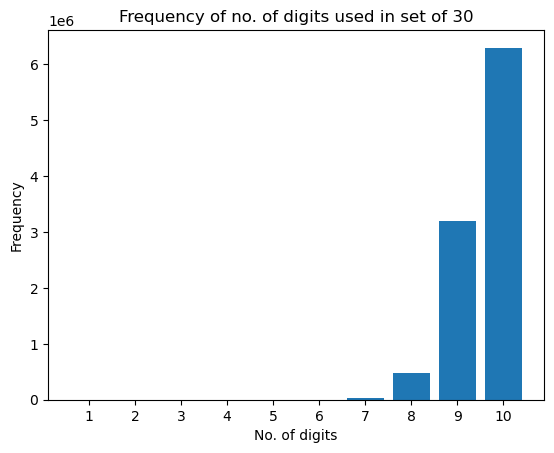

13 or more zeroes for 30 numbers = 151 times in 10000000 tests, probability of 1.51e-05 and a 1 in 66225.16556291391 chance.
21 or more zeroes or fives for 30 numbers = 1 times in 10000000 tests, probability of 1e-07 and a 1 in 10000000.0 chance.
Only 5 digits used = 19 times in 10000000 tests, probability of 1.9e-06 and a 1 in 526315.7894736842 chance.
processing time = 1121.899607181549


In [2]:
# Randomly generate 'total_gens' numbers between 0 and 9.
# also apply X+Y=Z dependency with modulus 10
# Count occurrence of each digit
# Categorise with number of different digits represented
# Do this millions of times to create a distribution
import random
import numpy as np
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(1) # change this to 1, 2 and 3 for tests
number_of_tests = 10000000 # do 10 millions tests to get enough precision of probabilities for rarer circumstances
total_gens = 10
start = time.time()

one_digit = 0
two_digits = 0
three_digits = 0
four_digits = 0
five_digits = 0
six_digits = 0
seven_digits = 0
eight_digits = 0
nine_digits = 0
ten_digits = 0
zero_13_counter = 0
five_zero_21_counter = 0
for n in range(0, number_of_tests, 1):
    zero_count = 0
    one_count = 0
    two_count = 0
    three_count = 0
    four_count = 0
    five_count = 0
    six_count = 0
    seven_count = 0
    eight_count = 0
    nine_count = 0
    
    rnd_nums_X_ones = rng.integers(low=0, high=10, size=total_gens)
    rnd_nums_Y_ones = rng.integers(low=0, high=10, size=total_gens)
    # now add each pair of numbers together (X+Y=Z -> with modulus 10 to extract the ending digit) 
    rnd_nums_Z_ones = np.mod(rnd_nums_X_ones + rnd_nums_Y_ones, 10)
    # now collapse into one big list
    rnd_nums = np.concatenate((rnd_nums_X_ones, rnd_nums_Y_ones, rnd_nums_Z_ones))
    for i in range(0, total_gens*3, 1):
        randnum = rnd_nums[i]
        if randnum == 0:
            zero_count = zero_count + 1
        elif randnum == 1:
            one_count = one_count + 1
        elif randnum == 2:
            two_count = two_count + 1
        elif randnum == 3:
            three_count = three_count + 1
        elif randnum == 4:
            four_count = four_count + 1
        elif randnum == 5:
            five_count = five_count + 1
        elif randnum == 6:
            six_count = six_count + 1
        elif randnum == 7:
            seven_count = seven_count + 1
        elif randnum == 8:
            eight_count = eight_count + 1
        elif randnum == 9:
            nine_count = nine_count + 1
        else:
            print("Error: random number generated is outside range or other error")

    # program loading bar feedback - can take a while!
    if n == int(number_of_tests/50):
        print("2% done after " + str(time.time() - start) + "")    
    if n == int(number_of_tests/10):
        print("10% done after " + str(time.time() - start))
    if n == int(number_of_tests/4):
        print("25% done after " + str(time.time() - start))
    if n == int(number_of_tests/2):
        print("50% done after " + str(time.time() - start))
    if n == int(number_of_tests/2 + number_of_tests/4):
        print("75% done after " + str(time.time() - start))
    
    nonzero_count = np.count_nonzero(np.array([zero_count, one_count, two_count, three_count, four_count, five_count, six_count, seven_count, eight_count, nine_count]))
    if nonzero_count == 10:
        ten_digits = ten_digits + 1
    elif nonzero_count == 9:
        nine_digits = nine_digits + 1
    elif nonzero_count == 8:
        eight_digits = eight_digits + 1
    elif nonzero_count == 7:
        seven_digits = seven_digits + 1
    elif nonzero_count == 6:
        six_digits = six_digits + 1
    elif nonzero_count == 5:
        five_digits = five_digits + 1
    elif nonzero_count == 4:
        four_digits = four_digits + 1
    elif nonzero_count == 3:
        three_digits = three_digits + 1
    elif nonzero_count == 2:
        two_digits = two_digits + 1
    elif nonzero_count == 1:
        one_digit = one_digit + 1
    elif nonzero_count == 0:
        print("Error: non zero count should never be 0")
    else:
        print("some other error occured")
    
    # now do counting for high occurrence of 5's and 0's
    if zero_count >= 13:
        zero_13_counter = zero_13_counter + 1
    if five_count + zero_count >= 21:
        five_zero_21_counter = five_zero_21_counter + 1

no_digits_appearing = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
frequency = [one_digit, two_digits, three_digits, four_digits, five_digits, six_digits, seven_digits, eight_digits, nine_digits, ten_digits]

plt.bar(no_digits_appearing, frequency)
plt.title('Frequency of no. of digits used in set of ' + str(total_gens*3))
plt.xlabel('No. of digits')
plt.ylabel('Frequency')
plt.show()

if total_gens == 10:
    print("13 or more zeroes for 30 numbers = " + str(zero_13_counter) + " times in " + str(number_of_tests) + 
          " tests, probability of " + str(zero_13_counter/number_of_tests) + " and a 1 in " + str(number_of_tests/zero_13_counter) + " chance.")
    print("21 or more zeroes or fives for 30 numbers = " + str(five_zero_21_counter) + " times in " + str(number_of_tests) + 
          " tests, probability of " + str(five_zero_21_counter/number_of_tests) + " and a 1 in " + str(number_of_tests/five_zero_21_counter) + " chance.")
    print("Only 5 digits used = " + str(five_digits) + " times in " + str(number_of_tests) + 
          " tests, probability of " + str(five_digits/number_of_tests) + " and a 1 in " + str(number_of_tests/five_digits) + " chance.")
else:
    prints("results are for a different number of generations to Genesis 5 or 11")

print("processing time = " + str(time.time() - start))